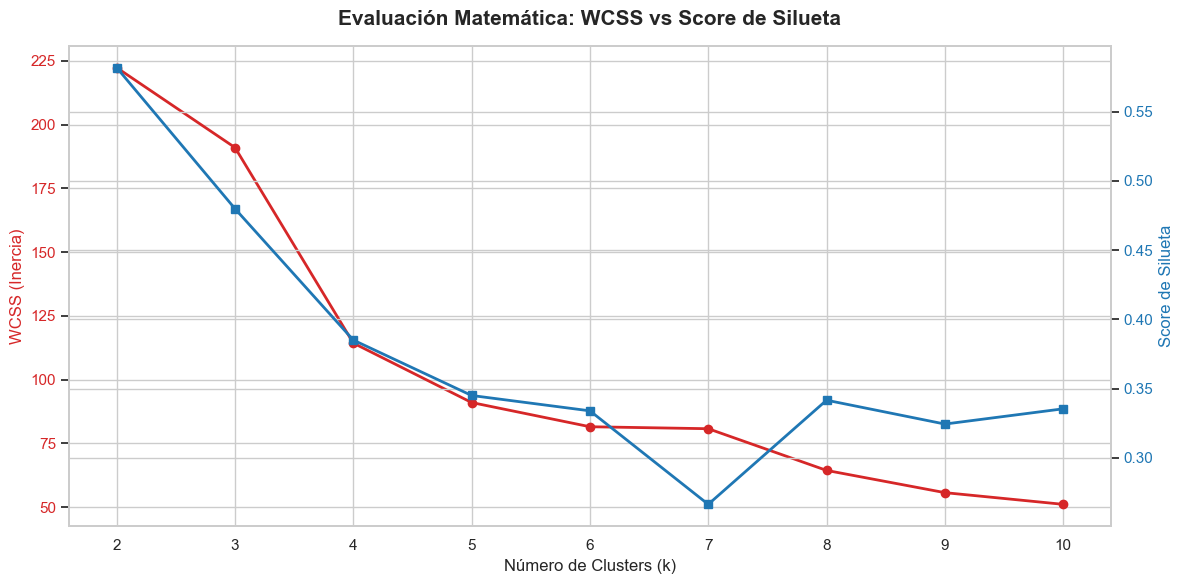

✅ Éxito: Los 2 Componentes Principales explican el 95.81% de los datos originales.


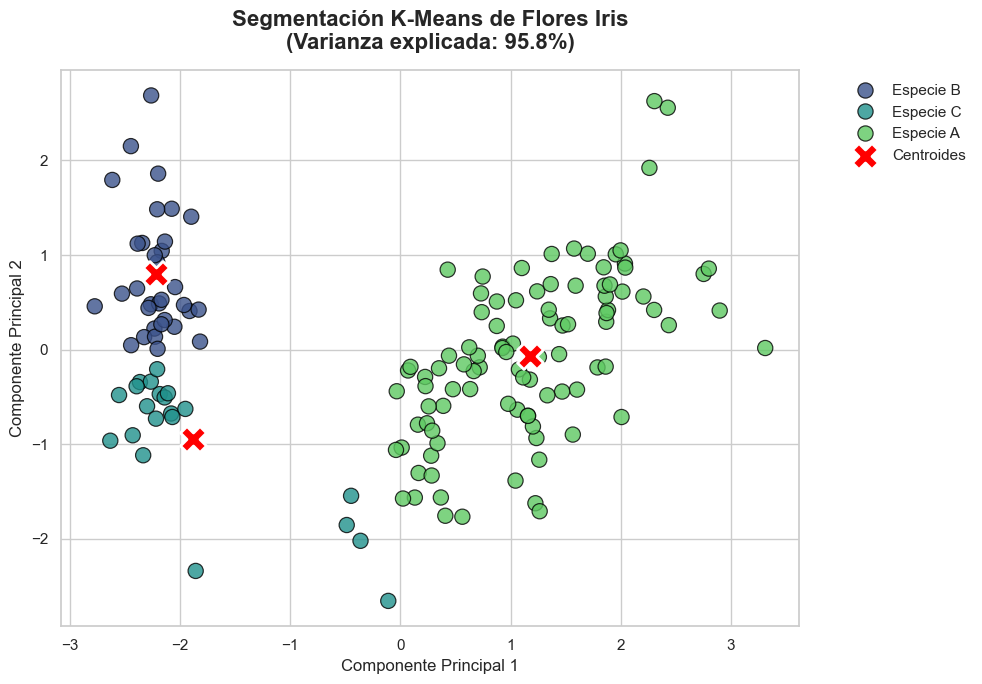

In [1]:
# =========================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import os
import warnings

warnings.filterwarnings('ignore') # Ocultamos advertencias visuales
sns.set_theme(style="whitegrid") # Estilo ejecutivo para gráficas

# =========================================================
# 2. CARGA Y LIMPIEZA DE DATOS
# =========================================================
# Ruta configurada según tu entorno de trabajo
ruta_ebac = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 5 Aprendizaje de máquina no supervisado\MOD 2 El Algoritmo K-Means"
os.chdir(ruta_ebac)

df = pd.read_csv("iris.csv")

# Separamos solo las variables numéricas (K-Means requiere matemáticas puras)
# Si el dataset trae la columna 'species', la ignoramos para el clustering
X = df.select_dtypes(include=[np.number])

# =========================================================
# 3. ESCALADO DE DATOS (REQUISITO INDISPENSABLE)
# =========================================================
# Nivelamos las medidas para que ninguna variable opaque a otra
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# 4. DETERMINAR 'K' ÓPTIMO (Codo de Jambú y Silueta)
# =========================================================
wcss = []
silhouette_scores = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))

# Graficamos ambas métricas en una sola figura ejecutiva
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:red'
ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('WCSS (Inercia)', color=color1, fontsize=12)
ax1.plot(rango_k, wcss, color=color1, marker='o', linewidth=2, label='Codo de Jambú')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  
color2 = 'tab:blue'
ax2.set_ylabel('Score de Silueta', color=color2, fontsize=12)
ax2.plot(rango_k, silhouette_scores, color=color2, marker='s', linewidth=2, label='Silueta')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Evaluación Matemática: WCSS vs Score de Silueta', fontsize=15, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# =========================================================
# 5. ENTRENAMIENTO DEL MODELO FINAL (K=3)
# =========================================================
# Matemáticamente, la silueta a veces sugiere k=2 para Iris, 
# pero por negocio/naturaleza sabemos que buscamos 3 perfiles.
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# =========================================================
# 6. REDUCCIÓN DE DIMENSIONES (PCA) Y VALIDACIÓN
# =========================================================
# Pasamos de 4 dimensiones (medidas de flor) a 2 Componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Validación crítica: ¿Cuánta información retuvimos?
varianza_retenida = pca.explained_variance_ratio_.sum() * 100
print(f"✅ Éxito: Los 2 Componentes Principales explican el {varianza_retenida:.2f}% de los datos originales.")

# =========================================================
# 7. VISUALIZACIÓN EJECUTIVA FINAL
# =========================================================
pca_df = pd.DataFrame(data=X_pca, columns=['Componente 1', 'Componente 2'])
pca_df['Perfil de Flor'] = clusters
pca_df['Perfil de Flor'] = pca_df['Perfil de Flor'].map({0: 'Especie A', 1: 'Especie B', 2: 'Especie C'})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente 1', 
    y='Componente 2',
    hue='Perfil de Flor',
    palette='viridis', 
    data=pca_df,
    s=120, 
    alpha=0.8, 
    edgecolor='black'
)

# Graficar Centroides transformados con PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroides_pca[:, 0], 
    centroides_pca[:, 1], 
    s=350, 
    c='red', 
    marker='X', 
    label='Centroides', 
    edgecolor='white',
    linewidths=2
)

plt.title(f'Segmentación K-Means de Flores Iris\n(Varianza explicada: {varianza_retenida:.1f}%)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()